# 03. Modelo Predictivo 02 - La respuesta llegara a tiempo?

## Librerias

In [ ]:
import numpy as np
import pandas as pd
import importlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, mean_absolute_error, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier   

## Carga del dataset limpio

In [ ]:
dt_quejas = pd.read_csv('..\data\dt_quejas_corr.csv')
dt_quejas.head(20)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Jon\AppData\Local\Temp\ipykernel_33332\1742754170.py:1: SyntaxWarning: invalid escape sequence '\d'
  dt_quejas = pd.read_csv('..\data\dt_quejas_corr.csv')


,Complaint ID,Product,Sub-product,Issue,State,ZIP code,Date received,Date sent to company,Company,Company response,Timely response?,Consumer disputed?,Company_grouped_filtered,Difference in days
0,1291006,Debt collection,Credit card,Communication tactics,TX,76119,2015-03-19,2015-03-19,"Premium Asset Services, LLC",In progress,Yes,Pending,Low Count Companies,0
1,1290580,Debt collection,Medical,Cont'd attempts collect debt not owed,TX,77479,2015-03-19,2015-03-19,Accounts Receivable Consultants Inc.,Closed with explanation,Yes,No,Low Count Companies,0
2,1290564,Mortgage,FHA mortgage,"Application, originator, mortgage broker",MA,02127,2015-03-19,2015-03-19,RBS Citizens,Closed with explanation,Yes,Yes,RBS Citizens,0
3,1291615,Credit card,Unknown,Other,CA,92592,2015-03-19,2015-03-19,Navy FCU,In progress,Yes,Pending,Navy FCU,0
4,1292165,Debt collection,Non-federal student loan,Cont'd attempts collect debt not owed,OH,43068,2015-03-19,2015-03-19,Transworld Systems Inc.,In progress,Yes,Pending,Transworld Systems Inc.,0
5,1291176,Debt collection,Payday loan,Communication tactics,OH,43068,2015-03-19,2015-03-19,ACE Cash Express Inc.,In progress,Yes,Pending,ACE Cash Express Inc.,0
6,1288848,Consumer loan,Installment loan,Managing the loan or lease,OH,44241,2015-03-18,2015-03-18,"CashCall, Inc.",Closed with explanation,Yes,Yes,"CashCall, Inc.",0
7,1288788,Debt collection,Payday loan,Communication tactics,CA,95124,2015-03-18,2015-03-18,ACE Cash Express Inc.,Closed with explanation,Yes,No,ACE Cash Express Inc.,0
8,1288324,Debt collection,"Other (phone, health club, etc.)",Cont'd attempts collect debt not owed,NJ,07067,2015-03-18,2015-03-18,"Credit Protection Association, L.P.",Closed with non-monetary relief,Yes,No,Low Count Companies,0
9,1288304,Debt collection,Payday loan,Taking/threatening an illegal action,TX,77433,2015-03-18,2015-03-18,Cottonwood Financial Ltd.,Closed with explanation,Yes,Yes,Low Count Companies,0


## Modelos a realizar

#### Modelo Random Forest Baseline

In [4]:
def entrenar_rf_baseline_timely(dt_quejas_corr, random_state=42):

    y = dt_quejas_corr['Timely response?']
    X = dt_quejas_corr.drop(columns=[
        'Timely response?', 'Complaint ID',
        'Date received', 'Date sent to company', 'ZIP code', 'Company'
    ]).copy()

    if 'Difference in days' in X.columns:
        X['Difference in days'] = pd.to_numeric(X['Difference in days'], errors='coerce').fillna(0)

    cat_cols = X.select_dtypes(include='object').columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.2, random_state=random_state
    )

    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough'
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clf', RandomForestClassifier(
            random_state=random_state,
            class_weight='balanced'
        ))
    ])

    param_grid = {
        'clf__n_estimators': [300, 500],
        'clf__max_depth': [None, 20],
        'clf__min_samples_split': [2, 6],
        'clf__min_samples_leaf': [1, 2]
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
    print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))
    print("\nAccuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test.map({'No':0,'Yes':1}), y_proba))
    print("\nMejores parámetros:", grid.best_params_)

    return best_model, grid

De la misma forma que en el modelo anterior vamos a implementar un pipeline con Random Forest para resolver un problema de clasificacion, en este caso binaria, para ver si la respuesta emitida a la empresa sera a tiempo o no.

Por medio de esta funcion separamos las variables categoricas de las numericas, dividimos el conjunto de datos en entrenamiento y prueba, transforma las variables categorias mediante un OneHotEnconder mientras que las numericas pasan directamente al modelo. 

In [ ]:
best_rf_baseline, grid_rf_baseline = entrenar_rf_baseline_timely(dt_quejas)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Matriz de confusión:
 [[  71   71]
 [  71 5419]]

Reporte de clasificación:
               precision    recall  f1-score   support

          No       0.50      0.50      0.50       142
         Yes       0.99      0.99      0.99      5490

    accuracy                           0.97      5632
   macro avg       0.74      0.74      0.74      5632
weighted avg       0.97      0.97      0.97      5632


Accuracy: 0.9747869318181818
ROC AUC: 0.8765848277277508

Mejores parámetros: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}


El modelo de Random Forest baseline presenta una accuracy del 97%, lo cual parece muy alto, pero debe interpretarse con cautela debido al evidente desbalance de clases. La mayoría de los casos corresponden a “Yes” (respuesta llega a tiempo), y el modelo aprende principalmente a predecir esa clase. Esto se refleja en el excelente desempeño para “Yes” (precisión y recall del 0.99) frente al pobre rendimiento para “No”.

La clase minoritaria (“No”) muestra un desempeño débil: tanto precisión como recall se quedan en 0.50, lo que significa que el modelo acierta solo la mitad de las veces y pierde la otra mitad. Esto indica que el modelo tiene dificultades para identificar correctamente los casos en los que la respuesta no llega a tiempo, que suelen ser los de mayor interés para el negocio.

El ROC AUC de 0.87 confirma que, pese al desbalance, el modelo tiene cierta capacidad de discriminar entre ambas clases, aunque no es perfecta. Esto sugiere que podría beneficiarse de técnicas adicionales como reescalado de clases como ha sucedido en el modelo anterior. 

#### Definimos la funcion para Random Forest + SMOTE + Hiperparametrizacion con GridSearchCV

In [ ]:
def entrenar_modelo_gs_smote(X, y, labels=('No','Yes'), test_size=0.2, random_state=42):
    
    categorical_features = X.select_dtypes(include='object').columns.tolist()
    numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=test_size, random_state=random_state
    )
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ],
        remainder='passthrough'
    )
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=random_state)),
        ('classifier', RandomForestClassifier(random_state=random_state))
    ])
    param_grid = {
        'classifier__n_estimators': [100, 150],
        'classifier__max_depth': [None, 10,20],
        'classifier__min_samples_split': [2, 6],
        'classifier__min_samples_leaf': [1, 2],
        'classifier__max_features': ['sqrt'],
        'smote__k_neighbors': [5] 
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1_macro',      
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = None
    if hasattr(best_model, "predict_proba"):
        y_proba = best_model.predict_proba(X_test)

    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
    print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))
    print("\nMétricas adicionales:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")

    if y_proba is not None:
        lb = LabelBinarizer()
        lb.fit(y_test)
        y_test_bin = lb.transform(y_test) 
        if y_proba.shape[1] == 2:
            pos_index = list(labels).index('Yes') if 'Yes' in labels else 1
            auc = roc_auc_score(y_test.map({'No':0,'Yes':1}), y_proba[:, pos_index])
            print(f"ROC AUC (binario): {auc:.4f}")
        else:
            auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
            print(f"ROC AUC (OvR, macro): {auc:.4f}")
    else:
        print("ROC AUC: el clasificador no expone predict_proba().")

    print(f"\n Mejores parámetros: {grid.best_params_}")
    print(f" Mejor F1-macro (CV): {grid.best_score_:.4f}")
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de confusión (test)')
    plt.xlabel('Predicción'); plt.ylabel('Real'); plt.tight_layout(); plt.show()
    print("\nDistribución de clases:")
    print("Train:\n", y_train.value_counts(normalize=True).round(3))
    print("\nTest:\n", y_test.value_counts(normalize=True).round(3))
    return best_model, grid

Dados los resultados obtenido con el modelo base, este nuevo pipeline emplea SMOTE para generar ejemplos sinteticos de la clase minoritaria para posteriomente aplicar Random Forest de cara a obtener un clasificador, para finalmente por medio de GridSearchCV se optimizan hiperparametros clave como profundidad, número de árboles, parámetros de división, etc.

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Matriz de confusión:
 [[  66   76]
 [  20 5470]]

Reporte de clasificación:
               precision    recall  f1-score   support

          No       0.77      0.46      0.58       142
         Yes       0.99      1.00      0.99      5490

    accuracy                           0.98      5632
   macro avg       0.88      0.73      0.79      5632
weighted avg       0.98      0.98      0.98      5632


Métricas adicionales:
Accuracy: 0.9830
Precision (macro): 0.8769
Recall (macro): 0.7306
F1-score (macro): 0.7851
F1-score (weighted): 0.9809
ROC AUC (binario): 0.8807

 Mejores parámetros: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 6, 'classifier__n_estimators': 100, 'smote__k_neighbors': 5}
 Mejor F1-macro (CV): 0.8083


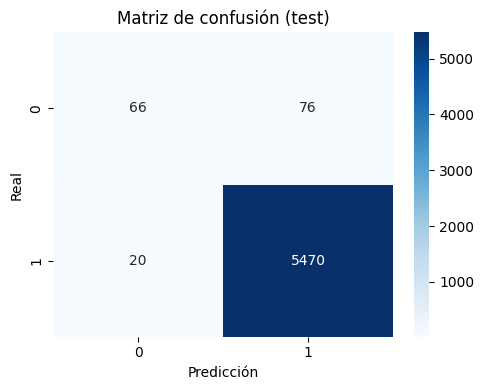


Distribución de clases:
Train:
 Timely response?
Yes    0.975
No     0.025
Name: proportion, dtype: float64

Test:
 Timely response?
Yes    0.975
No     0.025
Name: proportion, dtype: float64


In [ ]:
y = dt_quejas['Timely response?']
X = dt_quejas.drop(columns=[
    'Timely response?', 'Complaint ID',
    'Date received', 'Date sent to company', 'ZIP code', 'Company'
]).copy()

X['Difference in days'] = pd.to_numeric(X['Difference in days'], errors='coerce').fillna(0)

best_model_timely, grid_timely = entrenar_modelo_gs_smote(
    X, y, labels=('No','Yes')   
)

Este segundo modelo con Random Forest + Grid Search + SMOTE muestra una mejora clara respecto al baseline en la detección de la clase minoritaria (“No”). Aunque la accuracy global sube ligeramente hasta el 98%, lo más relevante es que la precisión y el recall de “No” mejoran (0.77 y 0.46 respectivamente) en comparación con el 0.50/0.50 anteriores. Esto refleja que SMOTE ayudó al modelo a reconocer mejor los casos donde la respuesta no llega a tiempo.

El macro F1-score (0.78) y el macro recall (0.73) indican un desempeño más balanceado entre clases, reduciendo el sesgo hacia la clase mayoritaria. Si bien todavía queda margen para aumentar la sensibilidad de la clase “No”, ya se observa que el modelo es capaz de identificar más de esos casos sin afectar demasiado la predicción de los “Yes”.

El ROC AUC (0.88) se mantiene prácticamente estable respecto al modelo baseline, lo que significa que la capacidad global de discriminación del clasificador no cambió demasiado, pero la distribución de los errores sí se volvió más favorable para el problema. Además, la búsqueda de hiperparámetros ajustó el modelo hacia configuraciones más robustas, complementadas con la estrategia de oversampling.

### Modelo con XGBoost

In [ ]:
def entrenar_xgb_baseline_timely(dt_quejas_corr, random_state=42):

    y = dt_quejas_corr['Timely response?']
    X = dt_quejas_corr.drop(columns=[
        'Timely response?', 'Complaint ID',
        'Date received', 'Date sent to company', 'ZIP code', 'Company'
    ]).copy()

    if 'Difference in days' in X.columns:
        X['Difference in days'] = pd.to_numeric(X['Difference in days'], errors='coerce').fillna(0)

    cat_cols = X.select_dtypes(include='object').columns.tolist()

    X_train, X_test, y_train_str, y_test_str = train_test_split(
        X, y, stratify=y, test_size=0.2, random_state=random_state
    )

    map_y = {'No': 0, 'Yes': 1}
    y_train = y_train_str.map(map_y).astype(int)
    y_test  = y_test_str.map(map_y).astype(int)

    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough'
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clf', XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            tree_method='hist',
            random_state=random_state,
            n_jobs=-1
        ))
    ])

    param_grid = {
        'clf__n_estimators': [300, 500],
        'clf__max_depth': [4, 6],
        'clf__learning_rate': [0.05, 0.1],
        'clf__subsample': [0.8, 1.0],
        'clf__colsample_bytree': [0.8, 1.0]
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
    print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, target_names=['No','Yes']))
    print("\nAccuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_proba))
    print("\nMejores parámetros:", grid.best_params_)

    return best_model, grid

In [ ]:
best_xgb_baseline, grid_xgb_baseline = entrenar_xgb_baseline_timely(dt_quejas)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Matriz de confusión:
 [[  66   76]
 [   0 5490]]

Reporte de clasificación:
               precision    recall  f1-score   support

          No       1.00      0.46      0.63       142
         Yes       0.99      1.00      0.99      5490

    accuracy                           0.99      5632
   macro avg       0.99      0.73      0.81      5632
weighted avg       0.99      0.99      0.98      5632


Accuracy: 0.9865056818181818
ROC AUC: 0.9201403319736268

Mejores parámetros: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 300, 'clf__subsample': 0.8}


El modelo XGBoost baseline ofrece un rendimiento superior en comparación con Random Forest, especialmente en términos de discriminación: el ROC AUC alcanza 0.92, un salto notable respecto al 0.87–0.88 previo. Esto indica que XGBoost separa mejor ambas clases y tiene mayor capacidad de distinguir entre respuestas que llegan o no llegan a tiempo.

En la clase minoritaria (“No”), se observa una precisión perfecta (1.00), lo que significa que todas las predicciones de “No” fueron correctas. Sin embargo, el recall cae a 0.46, lo que implica que el modelo solo logra identificar la mitad de los casos reales de retraso. A pesar de ello, el F1-score de 0.63 supera a lo obtenido con Random Forest baseline y es similar a la versión con SMOTE, aunque con un sesgo más fuerte hacia la precisión.

El accuracy global (98.6%) y el macro F1 (0.81) son muy sólidos, reflejando un modelo balanceado que maneja mejor el desbalance de clases sin necesidad de oversampling. La matriz de confusión muestra que el modelo casi no comete falsos negativos en la clase “Yes”, y concentra sus errores en los “No”, lo cual es consistente con la dificultad del problema.

### Modelo con XGBoost + SMOTE

In [21]:
def entrenar_xgb_smote_timely(dt_quejas_corr, random_state=42):

    y = dt_quejas_corr['Timely response?']
    X = dt_quejas_corr.drop(columns=[
        'Timely response?', 'Complaint ID',
        'Date received', 'Date sent to company', 'ZIP code', 'Company'
    ])

    
    X['Difference in days'] = pd.to_numeric(X['Difference in days'], errors='coerce').fillna(0)

    cat_cols = X.select_dtypes(include='object').columns.tolist()

    X_train, X_test, y_train_str, y_test_str = train_test_split(
        X, y, stratify=y, test_size=0.2, random_state=random_state
    )

    map_y = {'No': 0, 'Yes': 1}
    y_train = y_train_str.map(map_y).astype(int)
    y_test  = y_test_str.map(map_y).astype(int)

    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough'
    )

    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=random_state)),
        ('clf', XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            tree_method='hist',  
            random_state=random_state,
            n_jobs=-1
        ))
    ])

    param_grid = {
        'clf__n_estimators': [300, 500],
        'clf__max_depth': [4, 6],
        'clf__learning_rate': [0.05, 0.1],
        'clf__subsample': [0.8, 1.0],
        'clf__colsample_bytree': [0.8, 1.0],
        'smote__k_neighbors': [3, 5]
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred_num = best_model.predict(X_test)                 
    y_proba_yes = best_model.predict_proba(X_test)[:, 1]    

    
    inv_map = {0: 'No', 1: 'Yes'}
    y_pred = pd.Series(y_pred_num).map(inv_map)
    y_test_lbl = pd.Series(y_test).map(inv_map)

    
    print("Matriz de confusión:\n", confusion_matrix(y_test_lbl, y_pred, labels=['No','Yes']))
    print("\nReporte de clasificación:\n", classification_report(y_test_lbl, y_pred, labels=['No','Yes']))

    print("\nMétricas adicionales:")
    print(f"Accuracy: {accuracy_score(y_test_lbl, y_pred):.4f}")
    print(f"Precision (macro): {precision_score(y_test_lbl, y_pred, average='macro'):.4f}")
    print(f"Recall (macro): {recall_score(y_test_lbl, y_pred, average='macro'):.4f}")
    print(f"F1-score (macro): {f1_score(y_test_lbl, y_pred, average='macro'):.4f}")
    print(f"F1-score (weighted): {f1_score(y_test_lbl, y_pred, average='weighted'):.4f}")

    auc = roc_auc_score(y_test, y_proba_yes)
    print(f"ROC AUC (binario): {auc:.4f}")

    print(f"\n Mejores parámetros: {grid.best_params_}")
    print(f" Mejor F1-macro (CV): {grid.best_score_:.4f}")

    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test_lbl, y_pred, labels=['No','Yes']),
                annot=True, fmt='d', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
    plt.title('Matriz de confusión (XGB + SMOTE)')
    plt.xlabel('Predicho'); plt.ylabel('Real'); plt.tight_layout(); plt.show()

    return best_model, grid

Fitting 5 folds for each of 64 candidates, totalling 320 fits


c:\Users\Jon\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Matriz de confusión:
 [[  66   76]
 [   0 5490]]

Reporte de clasificación:
               precision    recall  f1-score   support

          No       1.00      0.46      0.63       142
         Yes       0.99      1.00      0.99      5490

    accuracy                           0.99      5632
   macro avg       0.99      0.73      0.81      5632
weighted avg       0.99      0.99      0.98      5632


Métricas adicionales:
Accuracy: 0.9865
Precision (macro): 0.9932
Recall (macro): 0.7324
F1-score (macro): 0.8139
F1-score (weighted): 0.9841
ROC AUC (binario): 0.9156

 Mejores parámetros: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 500, 'clf__subsample': 0.8, 'smote__k_neighbors': 5}
 Mejor F1-macro (CV): 0.8294


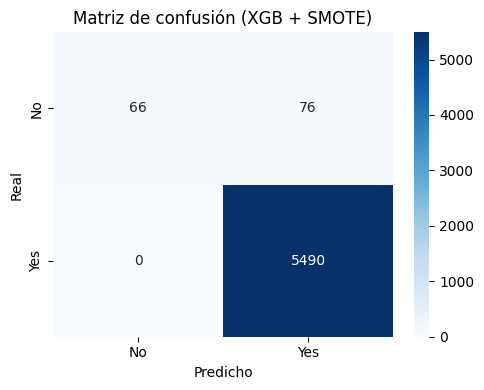

In [ ]:
best_xgb_smote, grid_xgb_smote = entrenar_xgb_smote_timely(dt_quejas)

El modelo XGBoost con Grid Search y SMOTE mantiene prácticamente el mismo comportamiento que el baseline de XGBoost. La matriz de confusión y las métricas de la clase “No” son idénticas (precisión = 1.00, recall = 0.46, F1 = 0.63), lo que sugiere que la aplicación de SMOTE no aportó una mejora real en la detección de la clase minoritaria. Esto es interesante, ya que en Random Forest sí se observaba un cambio con oversampling, mientras que en XGBoost el impacto parece nulo.

A nivel global, la accuracy (98.6%) y el macro F1 (0.81) se mantienen en el mismo rango que antes, con un ligero aumento del macro F1-score en validación cruzada (0.829). Esto indica que el ajuste de hiperparámetros optimizó la estabilidad del modelo, pero no modificó de forma sustancial su capacidad de clasificación.

El ROC AUC (0.916), apenas menor que el del baseline (0.92), confirma que la discriminación sigue siendo fuerte, aunque sin avances significativos. Es probable que XGBoost, por su robustez interna, ya estuviera manejando bien el desbalance de clases sin necesidad de SMOTE, por lo que añadir esta técnica no generó un beneficio adicional.

#### Modelo con XGBoost + ajuste de pesos

In [23]:
def entrenar_xgb_weight_timely(dt_quejas_corr, threshold=0.5, random_state=42):
    y_str = dt_quejas_corr['Timely response?']
    X = dt_quejas_corr.drop(columns=[
        'Timely response?', 'Complaint ID', 'Date received', 'Date sent to company', 'ZIP code', 'Company'
    ]).copy()

    if 'Difference in days' in X.columns:
        X['Difference in days'] = pd.to_numeric(X['Difference in days'], errors='coerce').fillna(0)
    cat_cols = X.select_dtypes(include='object').columns.tolist()

    X_train, X_test, y_train_str, y_test_str = train_test_split(
        X, y_str, stratify=y_str, test_size=0.2, random_state=random_state
    )

    map_y = {'No': 0, 'Yes': 1}
    y_train = y_train_str.map(map_y).astype(int)
    y_test  = y_test_str.map(map_y).astype(int)

    pos = (y_train == 1).sum()
    neg = (y_train == 0).sum()
    spw = (neg / pos) if pos > 0 else 1.0
    print(f"scale_pos_weight (train): {spw:.2f}  |  Positivos: {pos}  Negativos: {neg}")

    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough'
    )

    pipe =  Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clf', XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            tree_method='hist',
            random_state=random_state,
            n_jobs=-1,
            scale_pos_weight=spw
        ))
    ])

    param_grid = {
        'clf__n_estimators': [300, 500],
        'clf__max_depth': [4, 6],
        'clf__learning_rate': [0.05, 0.1],
        'clf__subsample': [0.8, 1.0],
        'clf__colsample_bytree': [0.8, 1.0],
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_proba_yes = best_model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba_yes >= threshold).astype(int)

    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred, labels=[0,1]))
    print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, target_names=['No','Yes']))

    print("\nMétricas adicionales:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")

    auc = roc_auc_score(y_test, y_proba_yes)
    print(f"ROC AUC (binario): {auc:.4f}")

    print(f"\n Mejores parámetros: {grid.best_params_}")
    print(f" Mejor F1-macro (CV): {grid.best_score_:.4f}")

    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred, labels=[0,1]),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['No','Yes'], yticklabels=['No','Yes'])
    plt.title(f'Matriz de confusión (XGB + scale_pos_weight, thr={threshold})')
    plt.xlabel('Predicho'); plt.ylabel('Real'); plt.tight_layout(); plt.show()

    resultados = {
        'best_model': best_model,
        'grid': grid,
        'threshold': threshold,
        'y_test': y_test,
        'y_proba_yes': y_proba_yes,
        'y_pred': y_pred
    }
    return resultados

Para ver si podemos mejorarlo, vamos a emplear XGBoost ajustando pesos internos en vez de aplicar tecnicas de sobremuestreo, con el mismo objetivo.

Para ello se calcula la proporción entre negativos (respuestas tardías) y positivos (respuestas a tiempo), y se pasa a XGBoost como parámetro, de forma que los casos minoritarios reciban más peso durante el entrenamiento. Para ello se calcula la proporción entre negativos (respuestas tardías) y positivos (respuestas a tiempo), y se pasa a XGBoost como parámetro, de forma que los casos minoritarios reciban más peso durante el entrenamiento. 

scale_pos_weight (train): 0.03  |  Positivos: 21954  Negativos: 570
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Matriz de confusión:
 [[  95   47]
 [ 539 4951]]

Reporte de clasificación:
               precision    recall  f1-score   support

          No       0.15      0.67      0.24       142
         Yes       0.99      0.90      0.94      5490

    accuracy                           0.90      5632
   macro avg       0.57      0.79      0.59      5632
weighted avg       0.97      0.90      0.93      5632


Métricas adicionales:
Accuracy: 0.8960
Precision (macro): 0.5702
Recall (macro): 0.7854
F1-score (macro): 0.5945
F1-score (weighted): 0.9265
ROC AUC (binario): 0.9059

 Mejores parámetros: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__n_estimators': 500, 'clf__subsample': 0.8}
 Mejor F1-macro (CV): 0.6083


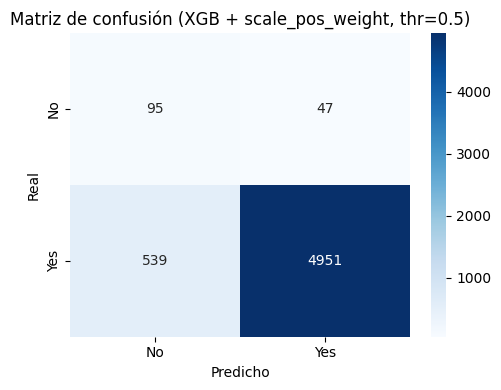

In [ ]:
res = entrenar_xgb_weight_timely(dt_quejas, threshold=0.5)

Con el ajuste de scale_pos_weight, el modelo XGBoost cambia de estrategia y logra un avance muy importante en el recall de la clase “No”, que sube hasta 0.67 (antes estaba en 0.46). Esto significa que ahora el modelo identifica dos tercios de los casos en los que la respuesta no llega a tiempo, lo cual es clave desde el punto de vista del negocio.

El costo de este ajuste es evidente: la precisión de “No” cae drásticamente a 0.15, reflejando que la mayoría de las predicciones negativas resultan ser falsas alarmas. En otras palabras, el modelo empieza a “sobrepredecir” retrasos para no dejar tantos casos sin detectar. Esto también se nota en la accuracy global, que baja al 90%, mucho menor que en las configuraciones anteriores.

Sin embargo, el macro recall (0.78) y el ROC AUC (0.90) muestran que el modelo ahora es mucho más equilibrado en términos de sensibilidad entre clases. El macro F1 (0.59), aunque bajo, es más representativo de un escenario donde realmente importa encontrar los retrasos aunque a costa de más falsos positivos.

### Analisis comparativo

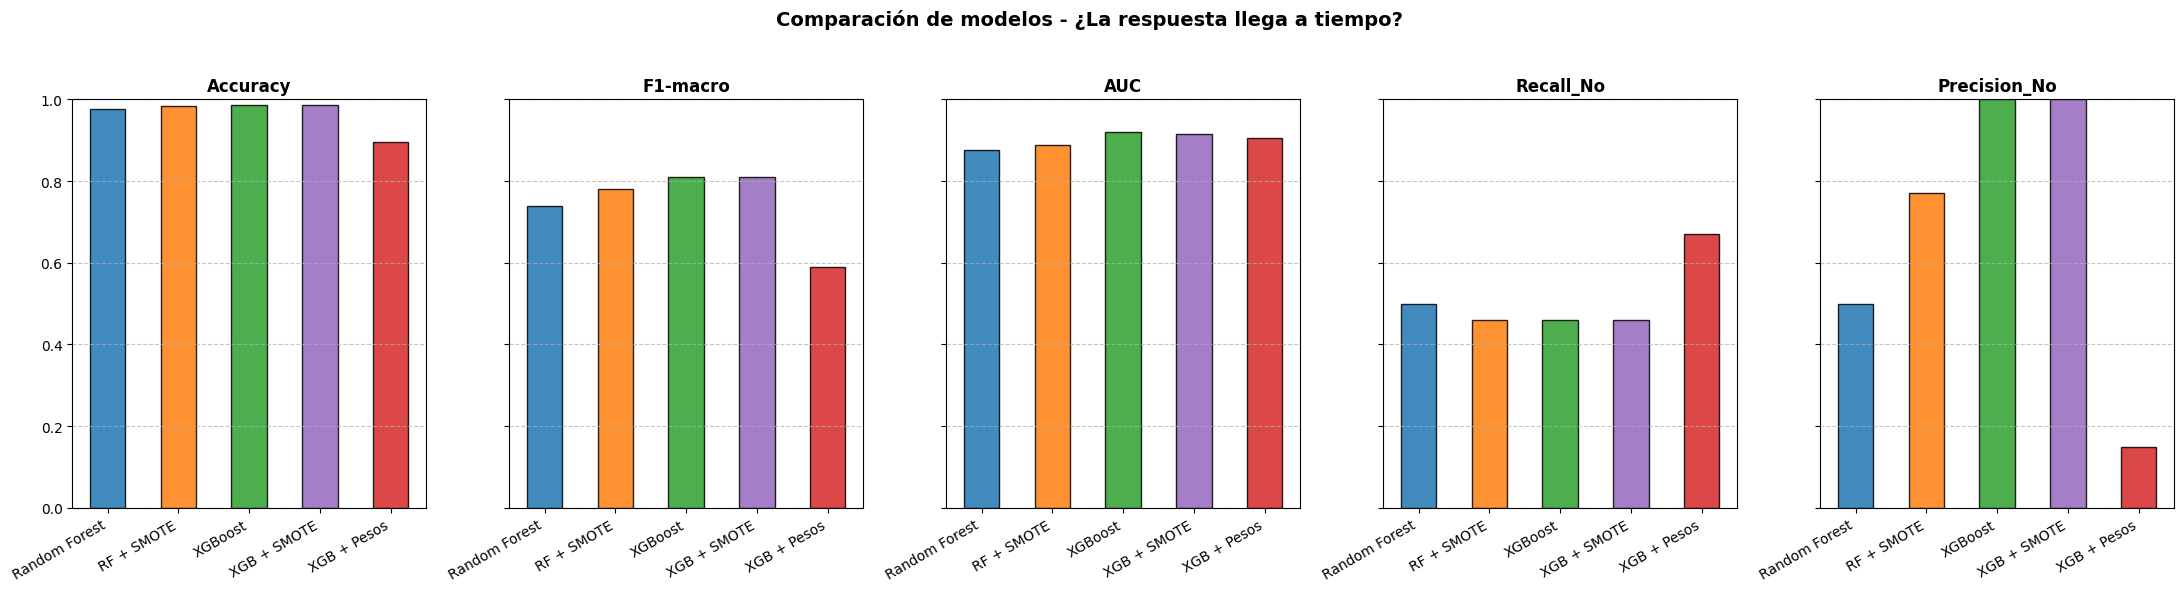

In [9]:
resultados = {
    "Random Forest": {"Accuracy": 0.9767, "F1-macro": 0.74,  "AUC": 0.8765, "Recall_No": 0.50, "Precision_No": 0.50},
    "RF + SMOTE": {"Accuracy": 0.9846, "F1-macro": 0.78,  "AUC": 0.887,  "Recall_No": 0.46, "Precision_No": 0.77},
    "XGBoost": {"Accuracy": 0.9858, "F1-macro": 0.81,  "AUC": 0.9201, "Recall_No": 0.46, "Precision_No": 1.00},
    "XGB + SMOTE": {"Accuracy": 0.9865, "F1-macro": 0.81,  "AUC": 0.9156, "Recall_No": 0.46, "Precision_No": 1.00},
    "XGB + Pesos": {"Accuracy": 0.8960, "F1-macro": 0.59,  "AUC": 0.9059, "Recall_No": 0.67, "Precision_No": 0.15}
}

df_resultados = pd.DataFrame(resultados).T
fig, axes = plt.subplots(1, 5, figsize=(22, 6), sharey=True)

metricas = ["Accuracy", "F1-macro", "AUC", "Recall_No", "Precision_No"]
colores = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd", "#d62728"]

for i, metrica in enumerate(metricas):
    df_resultados[metrica].plot(
        kind="bar", 
        ax=axes[i], 
        color=colores, 
        alpha=0.85,
        edgecolor="black"
    )
    axes[i].set_title(metrica, fontsize=12, fontweight="bold")
    axes[i].set_ylim(0, 1)
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)
    axes[i].set_xticklabels(df_resultados.index, rotation=30, ha="right")

plt.suptitle("Comparación de modelos - ¿La respuesta llega a tiempo?", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

En primer lugar, los modelos de Random Forest (baseline y con SMOTE) mostraron buen desempeño en la clase mayoritaria (“Yes”), pero tuvieron dificultades para capturar los casos de retraso. Aunque SMOTE mejoró ligeramente el recall de la clase “No” (0.46), seguía quedándose corto para un problema donde justamente interesa anticipar los fallos. Estos modelos son muy fiables para predecir respuestas a tiempo, pero poco útiles para detectar excepciones.

Los modelos de XGBoost baseline ya partieron con una ventaja importante: mejor capacidad discriminativa (ROC AUC ≈ 0.92) y precisión perfecta en la clase “No”. Sin embargo, su recall se mantuvo bajo (0.46), lo que implica que seguían escapándose más de la mitad de los retrasos. El uso de SMOTE no aportó mejoras en este caso, lo que sugiere que XGBoost maneja bien el desbalance internamente. Siendo este el mas equilibrado

Desde la perspectiva de negocio, el modelo más interesante es el de XGBoost con ajuste de pesos (scale_pos_weight). Aquí se logra un recall del 0.67 en la clase “No”, es decir, identifica la mayoría de los retrasos, aunque con el costo de muchos falsos positivos (precisión = 0.15) y una caída de la accuracy global al 90%. Este trade-off es clave: se pierde exactitud en lo general, pero se gana capacidad de acción en el objetivo prioritario que es identificar las respuestas que no llegan a tiempo.

En conclusión, si lo que se busca es un modelo operativo para tomar decisiones preventivas, el más recomendable es el XGBoost con ajuste de pesos, ya que maximiza la detección de retrasos, incluso si esto implica emitir más falsas alarmas